# Heterogeneous Au-in-Si Stress Test: WPM vs Angular Spectrum

This notebook is a deliberately sharp discriminator for the WPM vs angular-spectrum split-step methods.

**Proposed sample geometry:** a substitutional Au nanocolumn embedded in a Si host, continuous along the beam direction, with the probe centered on the Au/Si interface. The abrupt lateral high-Z/low-Z boundary creates strong transverse refractive-index variation inside every slice. Low beam energy and increased thickness are used to amplify any difference between local-index WPM propagation and angular-spectrum propagation with a separate phase grating.

This is not intended as the most realistic specimen first. It is an adversarial, interpretable geometry: if WPM and angular spectrum remain close here, that is strong evidence that the gap is small for practical samples; if they separate, this notebook should reveal where in angle/thickness/energy the split occurs.

## Why This Geometry Should Maximize the Gap

Angular spectrum MS applies a transmission step and then propagates through free space with the exact free-space longitudinal wavevector. WPM instead propagates each slice with a local refractive-index map, so its advantage can only become visible when the wavefront crosses strong transverse variation in potential during the propagation step.

The stress knobs in this notebook are therefore:

- **High-Z contrast:** Au column embedded in Si.
- **Abrupt lateral interface:** probe sits on the Au/Si edge, not in the center of a homogeneous region.
- **Low beam energy:** default sweep includes 60-200 keV; lower energy increases wavelength and interaction strength.
- **Thickness:** full mode uses a longer column so small per-slice differences can accumulate.
- **Optional potential scaling:** leave at 1.0 for physical atomistic potentials; increase only for a deliberately nonphysical propagation stress test.

In [1]:
%matplotlib inline

import os
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".35"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from ase.data import atomic_numbers
from matplotlib.colors import LogNorm, SymLogNorm

from wide_angle_propagation.propagation_methods import (
    Propagator,
    angular_spectrum_propagation_kernel,
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    wpm_step_adaptive,
    _lanczos_expsqrt,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

print(f"JAX backend: {jax.default_backend()}")

JAX backend: gpu


In [2]:
# Runtime mode. Start with quick_run=True to verify the geometry and code path.
quick_run = False

if quick_run:
    si_repeats_xy = (5, 5)
    si_repeats_z = 12
    n_slices_per_si_cell = 4
    potential_sampling = 0.25
    au_column_radius = 7.0
    probe_waist = 3.2
    energy_list = [60e3, 80e3, 120e3, 200e3]
    wpm_bins = 64
    run_kg_reference = False
    lanczos_m = 32
else:
    si_repeats_xy = (8, 8)
    si_repeats_z = 36
    n_slices_per_si_cell = 8
    potential_sampling = 0.15
    au_column_radius = 9.0
    probe_waist = 4.0
    energy_list = [40e3, 60e3, 80e3, 120e3, 200e3]
    wpm_bins = 128
    run_kg_reference = True
    lanczos_m = 80

# Leave this at 1.0 for a physical atomistic potential.
# Set to 2-4 only for a nonphysical stress test of propagation differences.
potential_scale = 1.0

# Probe is placed slightly inside the Au side of the Au/Si interface.
edge_fraction = 0.95
probe_tilt_x_mrad = 30.0

a_si = 5.431
unit_cell = bulk("Si", "diamond", a=a_si, cubic=True)
cell_thickness = float(unit_cell.cell[2, 2])
slice_dz = cell_thickness / n_slices_per_si_cell

print(f"Mode: {'quick' if quick_run else 'full'}")
print(f"Si repeats: {si_repeats_xy[0]} x {si_repeats_xy[1]} x {si_repeats_z}")
print(f"Slices per Si cell: {n_slices_per_si_cell}, dz = {slice_dz:.4f} Angstrom")
print(f"Energy sweep: {[int(e/1e3) for e in energy_list]} keV")
print(f"WPM bins: {wpm_bins}")
print(f"Potential scale: {potential_scale}")

Mode: full
Si repeats: 8 x 8 x 36
Slices per Si cell: 8, dz = 0.6789 Angstrom
Energy sweep: [40, 60, 80, 120, 200] keV
WPM bins: 128
Potential scale: 1.0


Total atoms: 18432
Au-substituted atoms: 2484 (13.5%)
Cell: 43.45 x 43.45 x 195.52 Angstrom
Au column radius: 9.00 Angstrom
Probe center: x=30.27, y=21.72 Angstrom


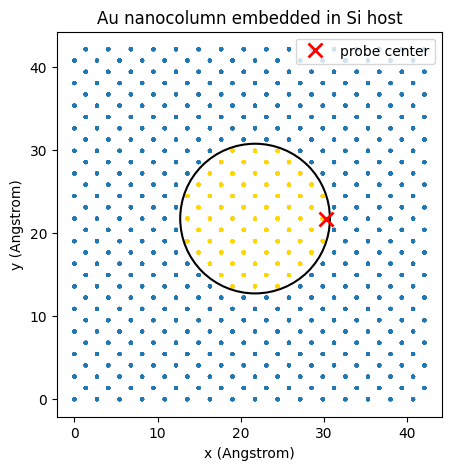

In [3]:
# Build a Si host and replace atoms inside a central cylinder with Au.
supercell = unit_cell * (*si_repeats_xy, si_repeats_z)
supercell.pbc = [True, True, True]

positions = supercell.get_positions()
lx, ly, lz = supercell.cell.lengths()
column_center_xy = np.array([lx / 2.0, ly / 2.0])
r_xy = np.linalg.norm(positions[:, :2] - column_center_xy[None, :], axis=1)
au_mask = r_xy <= au_column_radius

numbers = supercell.get_atomic_numbers()
numbers[au_mask] = atomic_numbers["Au"]
supercell.set_atomic_numbers(numbers)
supercell.info["thermal_sigma"] = 0.0
supercell.arrays["thermal_sigma"] = np.zeros(len(supercell))

probe_center_xy = (
    column_center_xy[0] + edge_fraction * au_column_radius,
    column_center_xy[1],
)

print(f"Total atoms: {len(supercell)}")
print(f"Au-substituted atoms: {int(au_mask.sum())} ({100 * au_mask.mean():.1f}%)")
print(f"Cell: {lx:.2f} x {ly:.2f} x {lz:.2f} Angstrom")
print(f"Au column radius: {au_column_radius:.2f} Angstrom")
print(f"Probe center: x={probe_center_xy[0]:.2f}, y={probe_center_xy[1]:.2f} Angstrom")

fig, ax = plt.subplots(figsize=(5, 5))
colors = np.where(au_mask, "gold", "tab:blue")
ax.scatter(positions[:, 0], positions[:, 1], s=8, c=colors, alpha=0.45, linewidths=0)
ax.add_patch(plt.Circle(column_center_xy, au_column_radius, fill=False, color="k", lw=1.5))
ax.plot(probe_center_xy[0], probe_center_xy[1], "rx", ms=10, mew=2, label="probe center")
ax.set_aspect("equal")
ax.set_xlabel("x (Angstrom)")
ax.set_ylabel("y (Angstrom)")
ax.set_title("Au nanocolumn embedded in Si host")
ax.legend(loc="upper right")
plt.show()

Building mixed Au/Si potential...
Potential built in 4.8s
Potential shape: (288, 290, 290) = slices x y x x
Grid: (290, 290), sampling = (0.1498, 0.1498) Angstrom
Potential range: [1.110, 1371.109] V


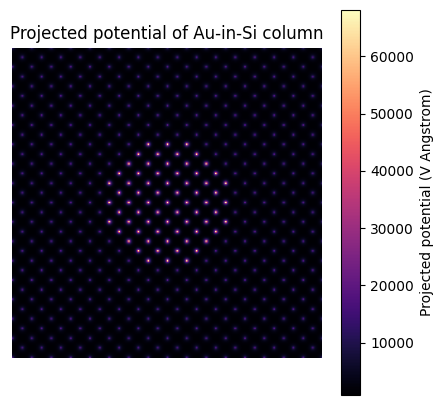

In [4]:
print("Building mixed Au/Si potential...")
t0 = perf_counter()
potential = abtem.Potential(
    supercell,
    sampling=potential_sampling,
    slice_thickness=slice_dz,
    projection="finite",
    parametrization="lobato",
)
gpts = tuple(potential.gpts)
sampling = (float(potential.sampling[0]), float(potential.sampling[1]))
pot_arr_np = cupy.asnumpy(potential.build(lazy=False).array / slice_dz)
pot_arr_np = potential_scale * pot_arr_np
pot_arr = jnp.array(pot_arr_np)
del potential
cupy.get_default_memory_pool().free_all_blocks()
elapsed = perf_counter() - t0

print(f"Potential built in {elapsed:.1f}s")
print(f"Potential shape: {pot_arr_np.shape} = slices x y x x")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Angstrom")
print(f"Potential range: [{pot_arr_np.min():.3f}, {pot_arr_np.max():.3f}] V")

projected = pot_arr_np.sum(axis=0) * slice_dz
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(projected, cmap="magma", origin="lower")
ax.set_title("Projected potential of Au-in-Si column")
ax.axis("off")
fig.colorbar(im, ax=ax, label="Projected potential (V Angstrom)")
plt.show()

In [5]:
def make_edge_gaussian_probe(shape, sampling, center_xy, waist, energy, tilt_x_mrad=0.0):
    ny, nx = shape
    dy, dx = sampling
    x = (np.arange(nx) + 0.5) * dx
    y = (np.arange(ny) + 0.5) * dy
    X, Y = np.meshgrid(x, y)
    x0, y0 = center_xy
    probe = np.exp(-((X - x0) ** 2 + (Y - y0) ** 2) / (2 * waist ** 2)).astype(np.complex128)
    if tilt_x_mrad != 0:
        wavelength = float(energy2wavelength(energy))
        kx0 = np.sin(tilt_x_mrad * 1e-3) / wavelength
        probe *= np.exp(2j * np.pi * kx0 * (X - x0))
    norm = np.sqrt(np.sum(np.abs(probe) ** 2))
    return jnp.array(probe / norm, dtype=jnp.complex128)

def diffraction_intensity(exit_wave):
    ew = np.asarray(exit_wave)
    return np.abs(np.fft.fftshift(np.fft.fft2(ew))) ** 2

def normalize_pattern(dp):
    arr = np.asarray(dp, dtype=np.float64)
    return arr / (arr.sum() + 1e-300)

def rel_l2(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-300))

def align_to_reference(test_wave, reference_wave):
    test = np.asarray(test_wave)
    ref = np.asarray(reference_wave)
    phase = np.angle(np.vdot(ref.ravel(), test.ravel()))
    return test * np.exp(-1j * phase)

def angle_grid_mrad(shape, sampling, energy):
    ny, nx = shape
    dy, dx = sampling
    wavelength = float(energy2wavelength(energy))
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=dy))
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))
    Fx, Fy = np.meshgrid(fx, fy)
    g = np.sqrt(Fx ** 2 + Fy ** 2)
    return 1000.0 * np.arcsin(np.clip(wavelength * g, 0.0, 1.0))

def annular_rel_l2(dp_a, dp_b, theta_mrad, bins):
    vals = []
    centers = 0.5 * (bins[:-1] + bins[1:])
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (theta_mrad >= lo) & (theta_mrad < hi)
        if mask.sum() < 4:
            vals.append(np.nan)
        else:
            vals.append(rel_l2(dp_a[mask], dp_b[mask]))
    return centers, np.array(vals)

def simulate_split_step_exit_only(potential, probe, prop_kernel, slice_thickness, energy):
    wavelength = energy2wavelength(energy)
    wavefront = probe
    for pot_slice in potential:
        n_map = electron_refractive_index(pot_slice, energy)
        phase_shift = jnp.exp(1j * 2 * jnp.pi * (n_map - 1.0) * slice_thickness / wavelength)
        wavefront = Propagator(wavefront * phase_shift, prop_kernel)
    return wavefront

def simulate_wpm_exit_only(potential, probe, slice_thickness, energy, sampling, n_bins=128, power_spacing=2.0):
    wavefront = probe
    for pot_slice in potential:
        n_map = electron_refractive_index(pot_slice, energy)
        wavefront, _, _, _ = wpm_step_adaptive(
            wavefront,
            n_map,
            slice_thickness,
            energy,
            sampling,
            n_bins=n_bins,
            power_spacing=power_spacing,
        )
    return wavefront

def simulate_kg_fwd_lanczos(potential, probe, slice_thickness, energy, sampling, lanczos_m=80):
    ny, nx = probe.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(energy)) ** 2
    dy, dx = sampling
    ky = 2 * jnp.pi * jnp.fft.fftfreq(ny, d=dy)
    kx = 2 * jnp.pi * jnp.fft.fftfreq(nx, d=dx)
    Kx, Ky = jnp.meshgrid(kx, ky)
    k_perp_sq = Kx ** 2 + Ky ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, energy) ** 2)(potential)
    state = jnp.fft.fft2(jnp.asarray(probe, dtype=jnp.complex128)).ravel() / (ny * nx)
    for n_sq in n_sq_all:
        def matvec(v):
            vg = v.reshape(ny, nx)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0_sq * conv - k_perp_sq * vg).ravel()
        state = _lanczos_expsqrt(matvec, state, slice_thickness, lanczos_m)
    return jnp.fft.ifft2(state.reshape(ny, nx)) * (ny * nx)

print("Helpers defined.")

Helpers defined.


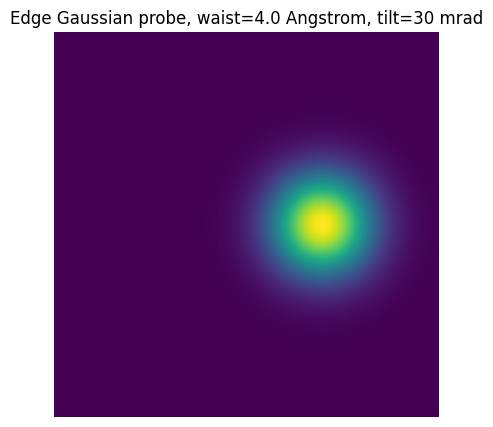

In [14]:
probe_preview = make_edge_gaussian_probe(
    gpts, sampling, probe_center_xy, probe_waist, energy_list[0], tilt_x_mrad=probe_tilt_x_mrad
)
probe_amp = np.abs(np.asarray(probe_preview))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(probe_amp, cmap="viridis", origin="lower")
ax.set_title(f"Edge Gaussian probe, waist={probe_waist:.1f} Angstrom, tilt={probe_tilt_x_mrad:.0f} mrad")
ax.axis("off")
plt.show()

In [7]:
results = []
exit_waves = {}
patterns = {}

for energy in energy_list:
    print(f"\n=== {energy/1e3:.0f} keV ===")
    probe = make_edge_gaussian_probe(
        gpts, sampling, probe_center_xy, probe_waist, energy, tilt_x_mrad=probe_tilt_x_mrad
    )
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

    t0 = perf_counter()
    ew_fresnel = simulate_split_step_exit_only(pot_arr, probe, fk, slice_dz, energy)
    jax.block_until_ready(ew_fresnel)
    dp_fresnel = diffraction_intensity(ew_fresnel)
    t_fresnel = perf_counter() - t0
    print(f"Fresnel: {t_fresnel:.2f}s")

    t0 = perf_counter()
    ew_as = simulate_split_step_exit_only(pot_arr, probe, ak, slice_dz, energy)
    jax.block_until_ready(ew_as)
    dp_as = diffraction_intensity(ew_as)
    t_as = perf_counter() - t0
    print(f"Angular spectrum: {t_as:.2f}s")

    t0 = perf_counter()
    ew_wpm = simulate_wpm_exit_only(pot_arr, probe, slice_dz, energy, sampling, n_bins=wpm_bins)
    jax.block_until_ready(ew_wpm)
    dp_wpm = diffraction_intensity(ew_wpm)
    t_wpm = perf_counter() - t0
    print(f"WPM: {t_wpm:.2f}s")

    dp_as_n = normalize_pattern(dp_as)
    dp_wpm_n = normalize_pattern(dp_wpm)
    dp_fresnel_n = normalize_pattern(dp_fresnel)
    ew_as_aligned = align_to_reference(ew_as, ew_wpm)
    ew_fresnel_aligned = align_to_reference(ew_fresnel, ew_wpm)

    row = {
        "energy_keV": energy / 1e3,
        "Fresnel_vs_WPM_DP": rel_l2(dp_fresnel_n, dp_wpm_n),
        "AS_vs_WPM_DP": rel_l2(dp_as_n, dp_wpm_n),
        "Fresnel_vs_WPM_exit": rel_l2(ew_fresnel_aligned, np.asarray(ew_wpm)),
        "AS_vs_WPM_exit": rel_l2(ew_as_aligned, np.asarray(ew_wpm)),
        "t_fresnel_s": t_fresnel,
        "t_as_s": t_as,
        "t_wpm_s": t_wpm,
    }

    if run_kg_reference:
        t0 = perf_counter()
        ew_kg = simulate_kg_fwd_lanczos(pot_arr, probe, slice_dz, energy, sampling, lanczos_m=lanczos_m)
        jax.block_until_ready(ew_kg)
        dp_kg = diffraction_intensity(ew_kg)
        t_kg = perf_counter() - t0
        dp_kg_n = normalize_pattern(dp_kg)
        row["AS_vs_KG_DP"] = rel_l2(dp_as_n, dp_kg_n)
        row["WPM_vs_KG_DP"] = rel_l2(dp_wpm_n, dp_kg_n)
        row["t_kg_s"] = t_kg
        patterns[(energy, "KG FWD")] = dp_kg
        exit_waves[(energy, "KG FWD")] = np.asarray(ew_kg)
        print(f"KG FWD Lanczos: {t_kg:.2f}s")

    results.append(row)
    patterns[(energy, "Fresnel")] = dp_fresnel
    patterns[(energy, "Angular Spectrum")] = dp_as
    patterns[(energy, "WPM")] = dp_wpm
    exit_waves[(energy, "Fresnel")] = np.asarray(ew_fresnel)
    exit_waves[(energy, "Angular Spectrum")] = np.asarray(ew_as)
    exit_waves[(energy, "WPM")] = np.asarray(ew_wpm)

    print(f"AS vs WPM DP rel L2: {row['AS_vs_WPM_DP']:.4e}")
    print(f"AS vs WPM exit rel L2: {row['AS_vs_WPM_exit']:.4e}")

print("\nEnergy sweep complete.")


=== 40 keV ===
Fresnel: 3.45s
Angular spectrum: 0.68s
WPM: 11.21s
KG FWD Lanczos: 114.23s
AS vs WPM DP rel L2: 1.9734e-03
AS vs WPM exit rel L2: 2.7365e-01

=== 60 keV ===
Fresnel: 1.11s
Angular spectrum: 1.18s
WPM: 9.23s
KG FWD Lanczos: 110.99s
AS vs WPM DP rel L2: 2.0046e-03
AS vs WPM exit rel L2: 2.0023e-01

=== 80 keV ===
Fresnel: 0.77s
Angular spectrum: 0.65s
WPM: 9.16s
KG FWD Lanczos: 110.69s
AS vs WPM DP rel L2: 1.9954e-03
AS vs WPM exit rel L2: 1.6972e-01

=== 120 keV ===
Fresnel: 0.81s
Angular spectrum: 0.92s
WPM: 8.93s
KG FWD Lanczos: 112.13s
AS vs WPM DP rel L2: 1.3846e-03
AS vs WPM exit rel L2: 1.1276e-01

=== 200 keV ===
Fresnel: 0.69s
Angular spectrum: 0.66s
WPM: 9.39s
KG FWD Lanczos: 112.37s
AS vs WPM DP rel L2: 2.0391e-03
AS vs WPM exit rel L2: 6.0741e-02

Energy sweep complete.


In [16]:
columns = [
    "energy_keV",
    "Fresnel_vs_WPM_DP",
    "AS_vs_WPM_DP",
    "Fresnel_vs_WPM_exit",
    "AS_vs_WPM_exit",
    "t_fresnel_s",
    "t_as_s",
    "t_wpm_s",
]
if run_kg_reference:
    columns += ["AS_vs_KG_DP", "WPM_vs_KG_DP", "t_kg_s"]

print("Method-gap summary for Au-in-Si edge probe")
print(" | ".join(f"{c:>20s}" for c in columns))
print("-" * (23 * len(columns)))
for row in results:
    vals = []
    for c in columns:
        val = row.get(c, np.nan)
        if c == "energy_keV":
            vals.append(f"{val:20.0f}")
        else:
            vals.append(f"{val:20.4e}")
    print(" | ".join(vals))

best_row = max(results, key=lambda r: r["Fresnel_vs_WPM_exit"])
best_energy = best_row["energy_keV"] * 1e3
print(f"\nLargest AS-WPM diffraction gap in this sweep: {best_row['AS_vs_WPM_DP']:.4e} at {best_row['energy_keV']:.0f} keV")
print(best_energy)

Method-gap summary for Au-in-Si edge probe
          energy_keV |    Fresnel_vs_WPM_DP |         AS_vs_WPM_DP |  Fresnel_vs_WPM_exit |       AS_vs_WPM_exit |          t_fresnel_s |               t_as_s |              t_wpm_s |          AS_vs_KG_DP |         WPM_vs_KG_DP |               t_kg_s
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                  40 |           1.5801e-02 |           1.9734e-03 |           2.0800e-01 |           2.7365e-01 |           3.4532e+00 |           6.8051e-01 |           1.1215e+01 |           7.9863e-03 |           7.0973e-03 |           1.1423e+02
                  60 |           6.1815e-03 |           2.0046e-03 |           1.0895e-01 |           2.0023e-01 |           1.1068e+00 |           1.1834e+00 |           9.2312e+00 |           8.9576e

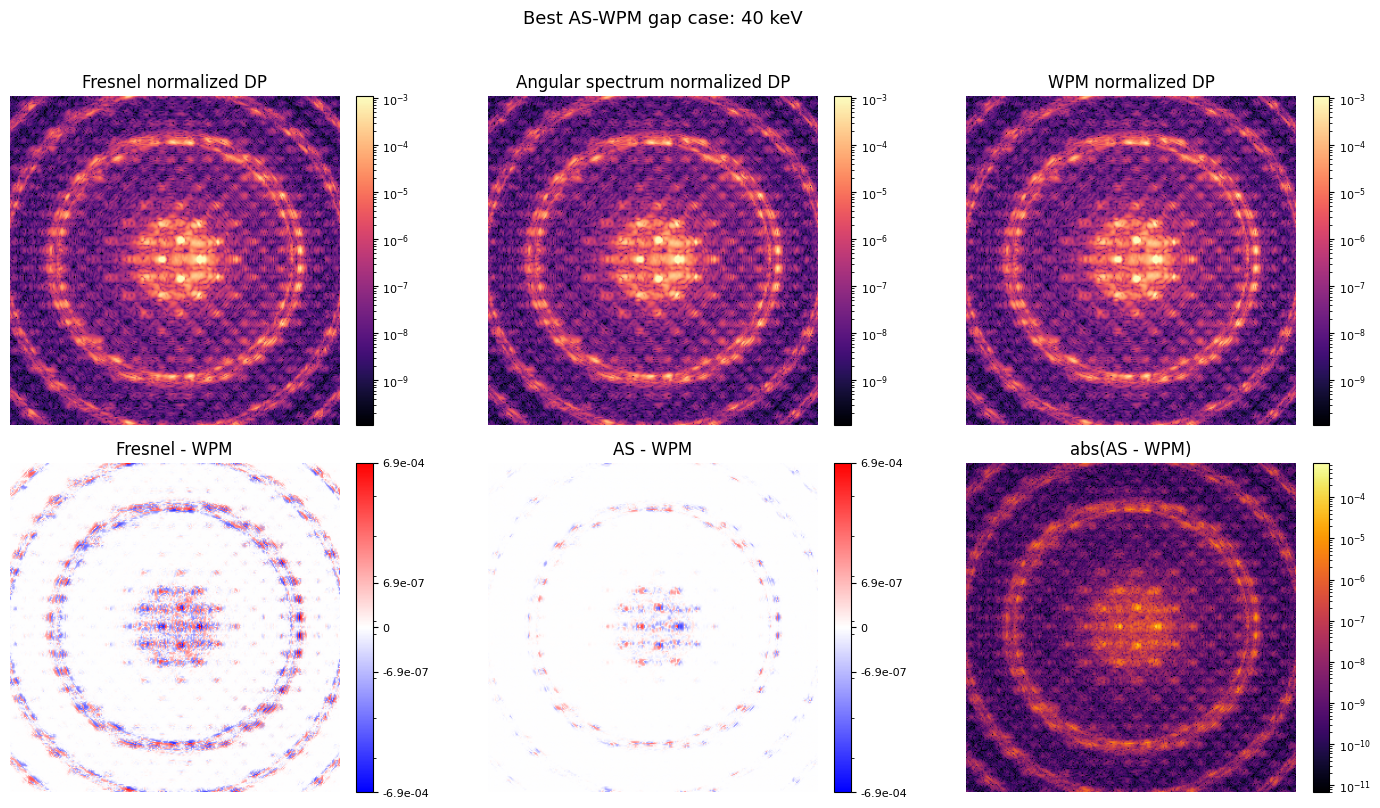

In [27]:
dp_as = patterns[(best_energy, "Angular Spectrum")]

dp_wpm = patterns[(best_energy, "WPM")]

dp_fresnel = patterns[(best_energy, "Fresnel")]

dp_as_n = normalize_pattern(dp_as)

dp_wpm_n = normalize_pattern(dp_wpm)

dp_fresnel_n = normalize_pattern(dp_fresnel)

diff_as_wpm = dp_as_n - dp_wpm_n

diff_fresnel_wpm = dp_fresnel_n - dp_wpm_n



vmax = max(np.percentile(dp_wpm_n[dp_wpm_n > 0], 99.9), 1e-16)

vmin = max(vmax * 1e-7, 1e-18)

diff_lim = max(np.max(np.abs(diff_as_wpm)), np.max(np.abs(diff_fresnel_wpm)), 1e-16)

diff_linthresh = max(diff_lim * 1e-3, 1e-18)

diff_norm = SymLogNorm(linthresh=diff_linthresh, vmin=-diff_lim, vmax=diff_lim)

diff_ticks = [-diff_lim, -diff_linthresh, 0.0, diff_linthresh, diff_lim]

diff_ticklabels = [

    f"{-diff_lim:.1e}",

    f"{-diff_linthresh:.1e}",

    "0",

    f"{diff_linthresh:.1e}",

    f"{diff_lim:.1e}",

]



fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.2))

entries = [

    (dp_fresnel_n, "Fresnel normalized DP", LogNorm(vmin=vmin, vmax=vmax), "magma", None, None),

    (dp_as_n, "Angular spectrum normalized DP", LogNorm(vmin=vmin, vmax=vmax), "magma", None, None),

    (dp_wpm_n, "WPM normalized DP", LogNorm(vmin=vmin, vmax=vmax), "magma", None, None),

    (diff_fresnel_wpm, "Fresnel - WPM", diff_norm, "bwr", diff_ticks, diff_ticklabels),

    (diff_as_wpm, "AS - WPM", diff_norm, "bwr", diff_ticks, diff_ticklabels),

    (np.abs(diff_as_wpm), "abs(AS - WPM)", LogNorm(vmin=max(diff_lim * 1e-8, 1e-20), vmax=diff_lim), "inferno", None, None),

]



for ax, (arr, title, norm, cmap, ticks, ticklabels) in zip(axes.ravel(), entries):

    im = ax.imshow(arr, origin="lower", cmap=cmap, norm=norm)

    ax.set_title(title)

    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    cbar.ax.tick_params(labelsize=8)

    if ticks is not None:

        cbar.set_ticks(ticks)

        cbar.set_ticklabels(ticklabels)



fig.suptitle(f"Best AS-WPM gap case: {best_energy/1e3:.0f} keV", fontsize=13)

fig.tight_layout(rect=(0, 0, 1, 0.96))

plt.show()

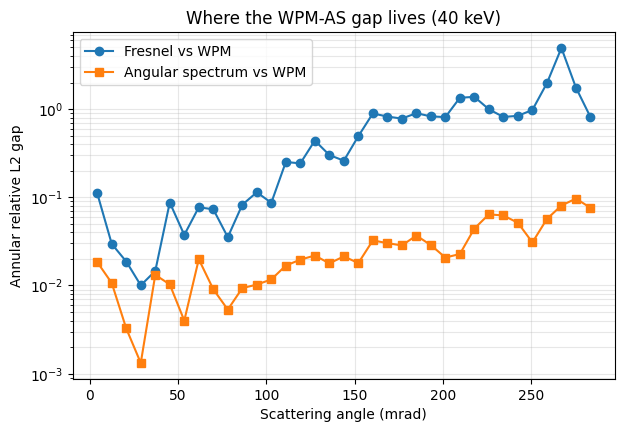

In [18]:
theta = angle_grid_mrad(gpts, sampling, best_energy)
max_theta = np.nanmax(theta)
bins = np.linspace(0, min(max_theta, 500), 36)
centers, ring_gap_as = annular_rel_l2(normalize_pattern(dp_as), normalize_pattern(dp_wpm), theta, bins)
_, ring_gap_fresnel = annular_rel_l2(normalize_pattern(dp_fresnel), normalize_pattern(dp_wpm), theta, bins)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(centers, ring_gap_fresnel, "o-", label="Fresnel vs WPM")
ax.semilogy(centers, ring_gap_as, "s-", label="Angular spectrum vs WPM")
ax.set_xlabel("Scattering angle (mrad)")
ax.set_ylabel("Annular relative L2 gap")
ax.set_title(f"Where the WPM-AS gap lives ({best_energy/1e3:.0f} keV)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

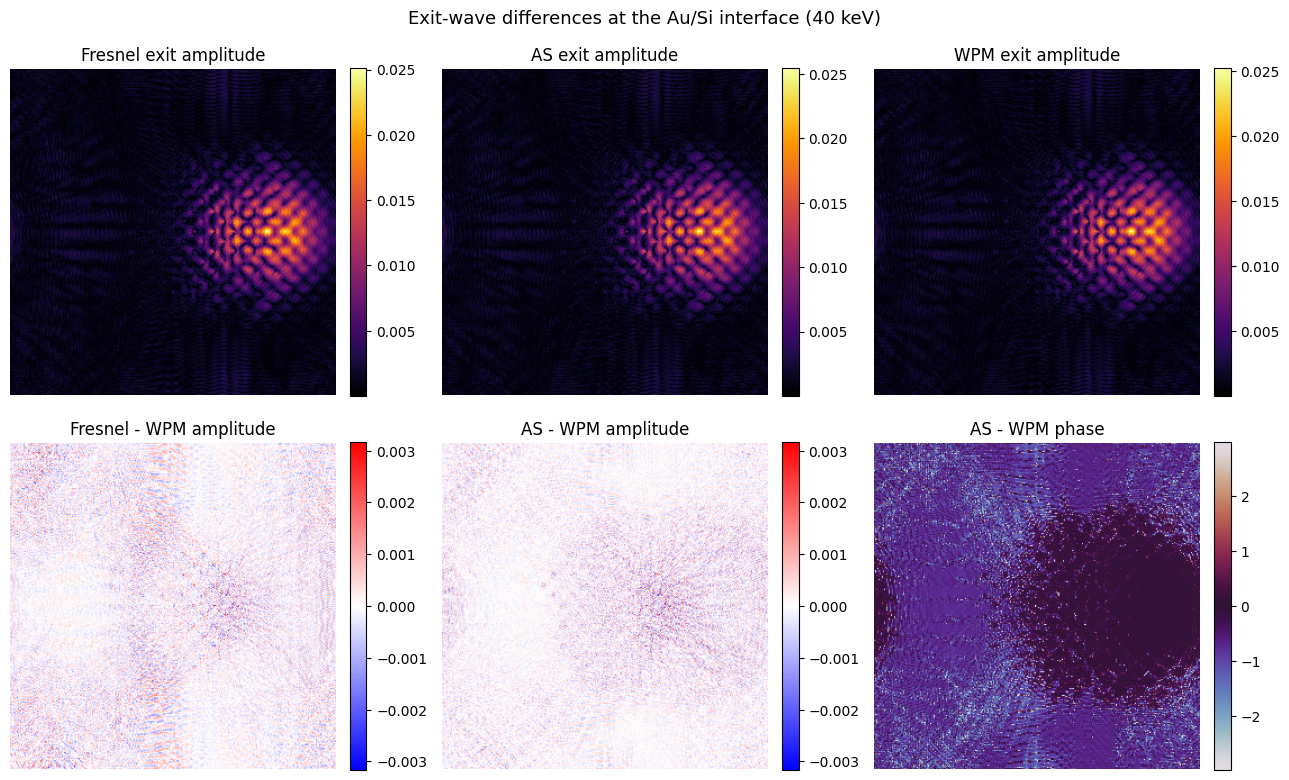

In [19]:
ew_as = exit_waves[(best_energy, "Angular Spectrum")]
ew_wpm = exit_waves[(best_energy, "WPM")]
ew_fresnel = exit_waves[(best_energy, "Fresnel")]
ew_as_aligned = align_to_reference(ew_as, ew_wpm)
ew_fresnel_aligned = align_to_reference(ew_fresnel, ew_wpm)

amp_wpm = np.abs(ew_wpm)
amp_diff_as = np.abs(ew_as_aligned) - amp_wpm
phase_diff_as = np.angle(ew_as_aligned * np.conj(ew_wpm))
phase_diff_fresnel = np.angle(ew_fresnel_aligned * np.conj(ew_wpm))

amp_lim = max(np.max(np.abs(amp_diff_as)), 1e-12)
phase_lim = max(np.percentile(np.abs(phase_diff_as), 99.5), np.percentile(np.abs(phase_diff_fresnel), 99.5), 1e-6)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
entries = [
    (np.abs(ew_fresnel), "Fresnel exit amplitude", "inferno", None),
    (np.abs(ew_as), "AS exit amplitude", "inferno", None),
    (amp_wpm, "WPM exit amplitude", "inferno", None),
    (np.abs(ew_fresnel_aligned) - amp_wpm, "Fresnel - WPM amplitude", "bwr", (-amp_lim, amp_lim)),
    (amp_diff_as, "AS - WPM amplitude", "bwr", (-amp_lim, amp_lim)),
    (phase_diff_as, "AS - WPM phase", "twilight", (-phase_lim, phase_lim)),
]

for ax, (arr, title, cmap, limits) in zip(axes.ravel(), entries):
    kwargs = {}
    if limits is not None:
        kwargs.update(vmin=limits[0], vmax=limits[1])
    im = ax.imshow(arr, origin="lower", cmap=cmap, **kwargs)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"Exit-wave differences at the Au/Si interface ({best_energy/1e3:.0f} keV)", fontsize=13)
fig.tight_layout()
plt.show()

## Optional: WPM Bin-Convergence Check

WPM uses refractive-index binning. Before interpreting a WPM-AS gap as physics, check that the WPM result is stable against the number of bins. This cell is off by default because it reruns WPM several times.

In [12]:
run_bin_convergence = False

if run_bin_convergence:
    bin_list = sorted(set([max(16, wpm_bins // 2), wpm_bins, wpm_bins * 2]))
    probe = make_edge_gaussian_probe(
        gpts, sampling, probe_center_xy, probe_waist, best_energy, tilt_x_mrad=probe_tilt_x_mrad
    )
    wpm_by_bins = {}
    for bins_i in bin_list:
        print(f"Running WPM with {bins_i} bins...")
        t0 = perf_counter()
        ew_i = simulate_wpm_exit_only(pot_arr, probe, slice_dz, best_energy, sampling, n_bins=bins_i)
        jax.block_until_ready(ew_i)
        dp_i = normalize_pattern(diffraction_intensity(ew_i))
        wpm_by_bins[bins_i] = dp_i
        print(f"  done in {perf_counter() - t0:.2f}s")

    ref_bins = bin_list[-1]
    print(f"\nRelative DP gap vs {ref_bins} bins")
    for bins_i in bin_list[:-1]:
        print(f"  {bins_i:4d} bins: {rel_l2(wpm_by_bins[bins_i], wpm_by_bins[ref_bins]):.4e}")
else:
    print("Set run_bin_convergence=True to check WPM bin convergence.")

Set run_bin_convergence=True to check WPM bin convergence.


## Interpretation Checklist

Use this notebook as a decision tool:

- If **AS vs WPM** stays small at 60 keV on the Au/Si edge probe, the paper's claim that angular spectrum captures the useful high-angle correction is quite robust.
- If **AS vs WPM** grows mainly at high scattering angles, the method gap is tied to local-index propagation of high-k components.
- If **AS vs WPM** grows with `potential_scale` but not at `potential_scale = 1.0`, the physically relevant gap may be small even though the numerical stress test can force a separation.
- If the optional KG reference is enabled, the important question becomes whether WPM or angular spectrum is closer to KG, not merely whether they differ from each other.